
FFM — Notebook 01: Feature Processing & BSQ Tokenizer Training
================================================================
Kaggle GPU Notebook

This notebook:
1. Processes raw parquet data into normalized feature matrices
2. Patchifies features into temporal patches
3. Trains the BSQ autoencoder to learn a discrete vocabulary
4. Tokenizes all data and creates training sequences
5. Saves everything for the pre-training notebook

Expected runtime: 1-2 hours on Kaggle GPU


# ── Cell 1: Setup ──────────────────────────────────────────────────────────
# %% [markdown]
# # FFM — Phase 1: Feature Engineering & BSQ Tokenizer Training
# Process raw M1 data → normalized features → BSQ tokens → training sequences

In [1]:
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Install extras if on Kaggle
if os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
    os.system("pip install -q einops safetensors")

# Add src to path
PROJECT_ROOT = Path("/kaggle/input/datasets/theophilusmarcus/ffm-market-data") if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") else Path(".")
SRC_ROOT = Path("/kaggle/input/ffm-source") if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") else Path(".")
sys.path.insert(0, str(SRC_ROOT))

OUTPUT_DIR = Path("/kaggle/working") if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") else Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
PROCESSED_DIR = OUTPUT_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

RAW_DIR = PROJECT_ROOT / "raw" if (PROJECT_ROOT / "raw").exists() else PROJECT_ROOT 

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name()}")
    print(f"VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ── Cell 2: Configuration ─────────────────────────────────────────────────

Project root: /kaggle/input/datasets/theophilusmarcus/ffm-market-data
Raw data dir: /kaggle/input/datasets/theophilusmarcus/ffm-market-data
Output dir:   /kaggle/working
PyTorch: 2.10.0+cu128
CUDA:    True
GPU:     Tesla T4
VRAM:    14.6 GB


In [2]:
# ── Configuration (inline to avoid import issues on Kaggle) ──
PATCH_LENGTH = 16
FEATURE_DIM = 32
BSQ_EMBED_DIM = 64
BSQ_HIDDEN_DIM = 128
BSQ_NUM_BITS = 12
VOCAB_SIZE = 2 ** BSQ_NUM_BITS  # 4096
CONTEXT_LENGTH = 2048
HOLDOUT_START = "2022-01-01"

EMA_PERIODS = [3, 5, 8, 13, 21, 34, 55, 89]
REALIZED_VOL_WINDOW = 16

TOKENIZER_LR = 1e-3
TOKENIZER_EPOCHS = 50
TOKENIZER_BATCH_SIZE = 512
ENTROPY_WEIGHT = 0.1

print(f"Patch length:   {PATCH_LENGTH}")
print(f"Feature dim:    {FEATURE_DIM}")
print(f"BSQ bits:       {BSQ_NUM_BITS} → vocab size = {VOCAB_SIZE}")
print(f"Context length: {CONTEXT_LENGTH}")

# ── Cell 3: Load & Process Raw Data ───────────────────────────────────────

Patch length:   16
Feature dim:    32
BSQ bits:       12 → vocab size = 4096
Context length: 2048


In [3]:
EPS = 1e-10

def build_features(df):
    """Build feature matrix from OHLCV DataFrame."""
    # Ensure datetime
    if not pd.api.types.is_datetime64_any_dtype(df["datetime"]):
        df["datetime"] = pd.to_datetime(df["datetime"])

    close = df["close"]
    features = pd.DataFrame(index=df.index)

    # Log returns (3)
    features["logret_close"] = np.log(close / close.shift(1).clip(lower=EPS))
    features["logret_high"] = np.log(df["high"] / df["high"].shift(1).clip(lower=EPS))
    features["logret_low"] = np.log(df["low"] / df["low"].shift(1).clip(lower=EPS))

    # Spread proxy (1)
    features["spread_proxy"] = (df["high"] - df["low"]) / close.clip(lower=EPS)

    # Volume delta (1)
    bar_range = (df["high"] - df["low"]).clip(lower=EPS)
    direction = (close - df["open"]) / bar_range
    vol = df["volume"] if "volume" in df.columns else 0.0
    features["vol_delta"] = direction * np.log1p(vol)

    # Realized vol (1)
    features["realized_vol"] = features["logret_close"].rolling(REALIZED_VOL_WINDOW, min_periods=1).std()

    # Bar ratios (2)
    features["range_ratio"] = bar_range / close.clip(lower=EPS)
    features["body_ratio"] = (close - df["open"]).abs() / bar_range

    # EMA rainbow deviations + slopes (8 + 8 = 16)
    for p in EMA_PERIODS:
        ema = close.ewm(span=p, adjust=False).mean()
        features[f"ema_dev_{p}"] = (close - ema) / close.clip(lower=EPS)
        features[f"ema_slope_{p}"] = ema / ema.shift(1).clip(lower=EPS) - 1.0

    # Time encoding (1)
    hour = df["datetime"].dt.hour + df["datetime"].dt.minute / 60.0
    features["time_sin"] = np.sin(2 * np.pi * hour / 24.0)

    # Total so far: 3 + 1 + 1 + 1 + 2 + 16 + 1 = 25 columns
    # Pad to FEATURE_DIM
    n_cols = features.shape[1]
    if n_cols < FEATURE_DIM:
        for i in range(FEATURE_DIM - n_cols):
            features[f"_pad_{i}"] = 0.0

    result = features.values[:, :FEATURE_DIM].astype(np.float32)
    return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)


# Process all symbols
manifest_path = RAW_DIR / "manifest.json"
with open(manifest_path) as f:
    manifest = json.load(f)

holdout_dt = pd.Timestamp(HOLDOUT_START, tz="UTC")

all_train_features = []
symbol_metadata = {}

print(f"\nProcessing {len(manifest['symbols'])} symbols...")
print(f"Hold-out split: {HOLDOUT_START}")
print("-" * 60)

for symbol, info in manifest["symbols"].items():
    t0 = time.time()
    fpath = RAW_DIR / info["file"]
    df = pd.read_parquet(fpath)
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)

    features = build_features(df)

    # Split
    mask_train = df["datetime"] < holdout_dt
    train_feats = features[mask_train.values]
    test_feats = features[~mask_train.values]

    all_train_features.append(train_feats)

    # Save processed features
    np.savez_compressed(
        PROCESSED_DIR / f"{symbol}_features.npz",
        train=train_feats,
        test=test_feats,
    )

    symbol_metadata[symbol] = {
        "train_samples": len(train_feats),
        "test_samples": len(test_feats),
    }

    elapsed = time.time() - t0
    print(f"  {symbol:10s} | train: {len(train_feats):>10,} | test: {len(test_feats):>8,} | {elapsed:.1f}s")

# Global normalization stats
combined_train = np.concatenate(all_train_features, axis=0)
mean = np.mean(combined_train, axis=0).astype(np.float32)
std = np.std(combined_train, axis=0).astype(np.float32)
std = np.where(std < EPS, 1.0, std)

np.savez(PROCESSED_DIR / "norm_stats.npz", mean=mean, std=std)
print(f"\nTotal training samples: {len(combined_train):,}")
print(f"Feature dim: {combined_train.shape[1]}")

del combined_train  # Free memory

# ── Cell 4: Normalize Features ────────────────────────────────────────────


Processing 12 symbols...
Hold-out split: 2022-01-01
------------------------------------------------------------
  XAUUSD     | train:  5,308,014 | test: 1,622,832 | 43.8s
  XAGUSD     | train:  4,319,560 | test: 1,639,088 | 38.4s
  XPTUSD     | train:  1,655,405 | test: 1,633,692 | 20.0s
  XPDUSD     | train:  1,371,894 | test: 1,611,382 | 18.6s
  EURUSD     | train:  6,190,119 | test: 1,714,986 | 49.9s
  GBPUSD     | train:  6,164,236 | test: 1,714,723 | 49.6s
  USDJPY     | train:  6,200,879 | test: 1,714,679 | 50.5s
  USDCHF     | train:  6,142,433 | test: 1,713,312 | 49.9s
  AUDUSD     | train:  6,118,626 | test: 1,714,313 | 49.9s
  USDCAD     | train:  6,028,622 | test: 1,714,163 | 49.4s
  NZDUSD     | train:  5,975,888 | test: 1,714,295 | 49.1s
  EURGBP     | train:  5,742,438 | test: 1,715,616 | 47.7s

Total training samples: 61,218,114
Feature dim: 32


In [4]:
print("Normalizing features...")
for symbol in manifest["symbols"]:
    data = np.load(PROCESSED_DIR / f"{symbol}_features.npz")
    train_normed = np.clip((data["train"] - mean) / std, -5, 5).astype(np.float32)
    test_normed = np.clip((data["test"] - mean) / std, -5, 5).astype(np.float32)

    np.savez_compressed(
        PROCESSED_DIR / f"{symbol}_features_normed.npz",
        train=train_normed,
        test=test_normed,
    )
    print(f"  {symbol}: train={train_normed.shape}, test={test_normed.shape}")

print("Done!")

# ── Cell 5: Patchify ──────────────────────────────────────────────────────

Normalizing features...
  XAUUSD: train=(5308014, 32), test=(1622832, 32)
  XAGUSD: train=(4319560, 32), test=(1639088, 32)
  XPTUSD: train=(1655405, 32), test=(1633692, 32)
  XPDUSD: train=(1371894, 32), test=(1611382, 32)
  EURUSD: train=(6190119, 32), test=(1714986, 32)
  GBPUSD: train=(6164236, 32), test=(1714723, 32)
  USDJPY: train=(6200879, 32), test=(1714679, 32)
  USDCHF: train=(6142433, 32), test=(1713312, 32)
  AUDUSD: train=(6118626, 32), test=(1714313, 32)
  USDCAD: train=(6028622, 32), test=(1714163, 32)
  NZDUSD: train=(5975888, 32), test=(1714295, 32)
  EURGBP: train=(5742438, 32), test=(1715616, 32)
Done!


In [5]:
def patchify(features, patch_length):
    T, D = features.shape
    n = T // patch_length
    return features[:n * patch_length].reshape(n, patch_length, D)

# Collect all training patches
all_patches = []
for symbol in manifest["symbols"]:
    data = np.load(PROCESSED_DIR / f"{symbol}_features_normed.npz")
    patches = patchify(data["train"], PATCH_LENGTH)
    flat = patches.reshape(patches.shape[0], -1)  # (N, L*D)
    all_patches.append(flat)
    print(f"  {symbol}: {len(flat):,} patches")

all_patches = np.concatenate(all_patches, axis=0)
print(f"\nTotal training patches: {all_patches.shape[0]:,}")
print(f"Patch vector dim: {all_patches.shape[1]}")

# ── Cell 6: BSQ Tokenizer Definition ──────────────────────────────────────

  XAUUSD: 331,750 patches
  XAGUSD: 269,972 patches
  XPTUSD: 103,462 patches
  XPDUSD: 85,743 patches
  EURUSD: 386,882 patches
  GBPUSD: 385,264 patches
  USDJPY: 387,554 patches
  USDCHF: 383,902 patches
  AUDUSD: 382,414 patches
  USDCAD: 376,788 patches
  NZDUSD: 373,493 patches
  EURGBP: 358,902 patches

Total training patches: 3,826,126
Patch vector dim: 512


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


class BSQEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, embed_dim, num_bits):
        super().__init__()
        self.num_bits = num_bits
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )
        self.q_proj = nn.Linear(embed_dim, num_bits, bias=False)
        self.register_buffer("powers", 2 ** torch.arange(num_bits - 1, -1, -1, dtype=torch.long))

    def forward(self, x):
        embeds = self.encoder(x)
        normed = F.normalize(embeds, p=2, dim=-1)
        logits = self.q_proj(normed)
        binary_hard = (logits >= 0).float()
        binary_codes = logits + (binary_hard - logits).detach()  # STE
        token_ids = (binary_codes * self.powers.float()).sum(dim=-1).long()
        return token_ids, binary_codes, embeds

    @torch.no_grad()
    def encode_numpy(self, x, batch_size=4096):
        device = next(self.parameters()).device
        all_ids = []
        for i in range(0, len(x), batch_size):
            batch = torch.from_numpy(x[i:i+batch_size]).float().to(device)
            ids, _, _ = self.forward(batch)
            all_ids.append(ids.cpu().numpy())
        return np.concatenate(all_ids)


class BSQDecoder(nn.Module):
    def __init__(self, output_dim, hidden_dim, embed_dim, num_bits):
        super().__init__()
        self.code_proj = nn.Linear(num_bits, embed_dim, bias=False)
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, binary_codes):
        return self.decoder(self.code_proj(binary_codes))


class BSQTokenizer(nn.Module):
    def __init__(self, input_dim, hidden_dim, embed_dim, num_bits, entropy_weight=0.1):
        super().__init__()
        self.num_bits = num_bits
        self.entropy_weight = entropy_weight
        self.encoder = BSQEncoder(input_dim, hidden_dim, embed_dim, num_bits)
        self.decoder = BSQDecoder(input_dim, hidden_dim, embed_dim, num_bits)

    def forward(self, x):
        token_ids, binary_codes, embeds = self.encoder(x)
        reconstruction = self.decoder(binary_codes)

        recon_loss = F.mse_loss(reconstruction, x)
        bit_probs = binary_codes.mean(dim=0)
        entropy_loss = F.binary_cross_entropy(
            bit_probs.clamp(1e-6, 1 - 1e-6),
            torch.full_like(bit_probs, 0.5),
        )
        total_loss = recon_loss + self.entropy_weight * entropy_loss

        return {
            "token_ids": token_ids,
            "binary_codes": binary_codes,
            "loss": total_loss,
            "recon_loss": recon_loss.item(),
            "entropy_loss": entropy_loss.item(),
        }


INPUT_DIM = PATCH_LENGTH * FEATURE_DIM
tokenizer = BSQTokenizer(INPUT_DIM, BSQ_HIDDEN_DIM, BSQ_EMBED_DIM, BSQ_NUM_BITS, ENTROPY_WEIGHT)
param_count = sum(p.numel() for p in tokenizer.parameters())
print(f"BSQ Tokenizer: {param_count:,} parameters")

# ── Cell 7: Train BSQ Tokenizer ───────────────────────────────────────────

BSQ Tokenizer: 149,824 parameters


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = tokenizer.to(device)

dataset = TensorDataset(torch.from_numpy(all_patches).float())
loader = DataLoader(dataset, batch_size=TOKENIZER_BATCH_SIZE, shuffle=True,
                    num_workers=2, pin_memory=True, drop_last=True)

optimizer = torch.optim.AdamW(tokenizer.parameters(), lr=TOKENIZER_LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOKENIZER_EPOCHS, eta_min=1e-5)

print(f"Training BSQ Tokenizer for {TOKENIZER_EPOCHS} epochs on {device}")
print(f"Batches per epoch: {len(loader)}")
print("-" * 60)

history = []
best_loss = float("inf")

for epoch in range(TOKENIZER_EPOCHS):
    tokenizer.train()
    ep_loss, ep_recon, ep_ent, n = 0, 0, 0, 0
    t0 = time.time()

    for (batch,) in loader:
        batch = batch.to(device, non_blocking=True)
        result = tokenizer(batch)
        loss = result["loss"]

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tokenizer.parameters(), 1.0)
        optimizer.step()

        ep_loss += loss.item()
        ep_recon += result["recon_loss"]
        ep_ent += result["entropy_loss"]
        n += 1

    scheduler.step()
    avg = ep_loss / n

    history.append({"epoch": epoch+1, "loss": avg, "recon": ep_recon/n, "entropy": ep_ent/n})

    if avg < best_loss:
        best_loss = avg
        torch.save(tokenizer.state_dict(), CHECKPOINT_DIR / "bsq_tokenizer_best.pt")

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{TOKENIZER_EPOCHS} | Loss: {avg:.6f} | "
              f"Recon: {ep_recon/n:.6f} | Entropy: {ep_ent/n:.6f} | {time.time()-t0:.1f}s")

torch.save(tokenizer.encoder.state_dict(), CHECKPOINT_DIR / "bsq_encoder.pt")
print(f"\nBest loss: {best_loss:.6f}")

# ── Cell 8: Codebook Analysis ─────────────────────────────────────────────

Training BSQ Tokenizer for 50 epochs on cuda
Batches per epoch: 7472
------------------------------------------------------------
  Epoch   1/50 | Loss: 0.376714 | Recon: 0.303622 | Entropy: 0.730920 | 40.6s
  Epoch   5/50 | Loss: 0.365876 | Recon: 0.293436 | Entropy: 0.724403 | 39.5s
  Epoch  10/50 | Loss: 0.367944 | Recon: 0.296396 | Entropy: 0.715478 | 39.8s
  Epoch  15/50 | Loss: 0.366805 | Recon: 0.295051 | Entropy: 0.717541 | 40.0s
  Epoch  20/50 | Loss: 0.366383 | Recon: 0.294431 | Entropy: 0.719511 | 39.8s
  Epoch  25/50 | Loss: 0.366174 | Recon: 0.293508 | Entropy: 0.726662 | 39.6s
  Epoch  30/50 | Loss: 0.368039 | Recon: 0.294754 | Entropy: 0.732850 | 39.7s
  Epoch  35/50 | Loss: 0.368901 | Recon: 0.295686 | Entropy: 0.732148 | 39.4s
  Epoch  40/50 | Loss: 0.369910 | Recon: 0.297313 | Entropy: 0.725970 | 39.4s
  Epoch  45/50 | Loss: 0.367657 | Recon: 0.295283 | Entropy: 0.723740 | 40.0s
  Epoch  50/50 | Loss: 0.367163 | Recon: 0.294879 | Entropy: 0.722836 | 39.8s

Best loss: 

Unique tokens used: 2604 / 4096
Utilization: 63.6%


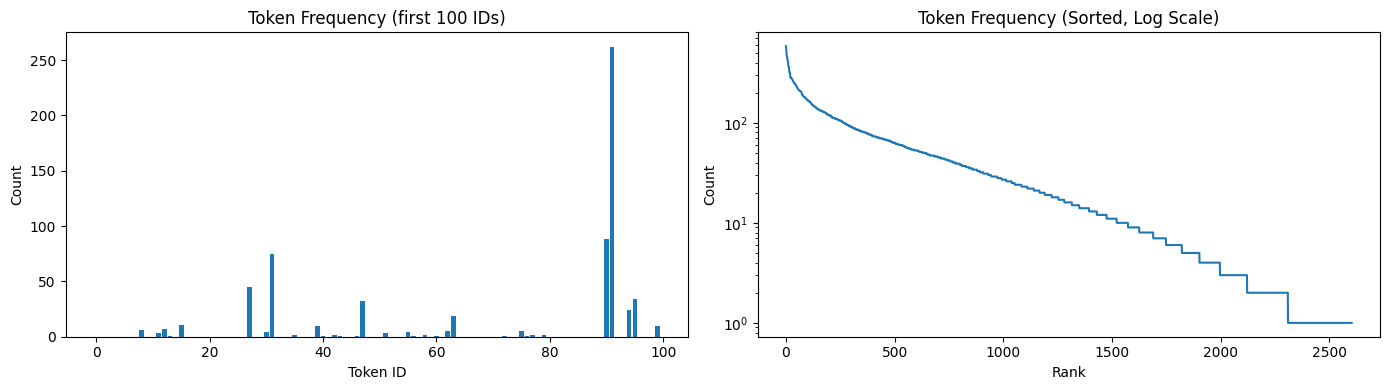

Saved codebook_analysis.png


In [8]:
tokenizer.eval()
sample = torch.from_numpy(all_patches[:100_000]).float().to(device)
with torch.no_grad():
    result = tokenizer(sample)
    ids = result["token_ids"]

unique = ids.unique()
counts = torch.bincount(ids, minlength=VOCAB_SIZE)

print(f"Unique tokens used: {len(unique)} / {VOCAB_SIZE}")
print(f"Utilization: {len(unique)/VOCAB_SIZE*100:.1f}%")

# Plot token distribution
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.bar(range(min(100, len(counts))), counts[:100].cpu().numpy())
plt.title("Token Frequency (first 100 IDs)")
plt.xlabel("Token ID")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sorted_counts = counts[counts > 0].sort(descending=True).values.cpu().numpy()
plt.plot(sorted_counts)
plt.title("Token Frequency (Sorted, Log Scale)")
plt.xlabel("Rank")
plt.ylabel("Count")
plt.yscale("log")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "codebook_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved codebook_analysis.png")

# ── Cell 9: Tokenize All Data & Create Sequences ──────────────────────────

In [9]:
print("Tokenizing all data and creating training sequences...")
STRIDE = CONTEXT_LENGTH // 2  # 50% overlap

all_sequences = []

for symbol in manifest["symbols"]:
    data = np.load(PROCESSED_DIR / f"{symbol}_features_normed.npz")

    # Training data
    train_feats = data["train"]
    patches = patchify(train_feats, PATCH_LENGTH)
    flat = patches.reshape(patches.shape[0], -1)

    # Tokenize
    token_ids = tokenizer.encoder.encode_numpy(flat, batch_size=8192)

    # Create sequences (context_length + 1 for input/target split)
    seq_len = CONTEXT_LENGTH + 1
    n_tokens = len(token_ids)

    if n_tokens >= seq_len:
        for start in range(0, n_tokens - seq_len + 1, STRIDE):
            seq = token_ids[start:start + seq_len]
            all_sequences.append(seq)

    print(f"  {symbol}: {n_tokens:,} tokens → {len(all_sequences):,} sequences (cumulative)")

    # Also save tokenized test data for evaluation
    test_feats = data["test"]
    if len(test_feats) >= PATCH_LENGTH:
        test_patches = patchify(test_feats, PATCH_LENGTH)
        test_flat = test_patches.reshape(test_patches.shape[0], -1)
        test_tokens = tokenizer.encoder.encode_numpy(test_flat, batch_size=8192)
        np.save(PROCESSED_DIR / f"{symbol}_test_tokens.npy", test_tokens)

all_sequences = np.array(all_sequences, dtype=np.int32)
print(f"\nTotal training sequences: {all_sequences.shape[0]:,}")
print(f"Sequence length: {all_sequences.shape[1]} (context + 1)")

# Shuffle
rng = np.random.default_rng(42)
rng.shuffle(all_sequences)

# Save
np.save(OUTPUT_DIR / "token_sequences.npy", all_sequences)
print(f"Saved to {OUTPUT_DIR / 'token_sequences.npy'}")
print(f"Size: {all_sequences.nbytes / 1024**2:.1f} MB")

# ── Cell 10: Summary ──────────────────────────────────────────────────────

Tokenizing all data and creating training sequences...
  XAUUSD: 331,750 tokens → 322 sequences (cumulative)
  XAGUSD: 269,972 tokens → 584 sequences (cumulative)
  XPTUSD: 103,462 tokens → 684 sequences (cumulative)
  XPDUSD: 85,743 tokens → 766 sequences (cumulative)
  EURUSD: 386,882 tokens → 1,142 sequences (cumulative)
  GBPUSD: 385,264 tokens → 1,517 sequences (cumulative)
  USDJPY: 387,554 tokens → 1,894 sequences (cumulative)
  USDCHF: 383,902 tokens → 2,267 sequences (cumulative)
  AUDUSD: 382,414 tokens → 2,639 sequences (cumulative)
  USDCAD: 376,788 tokens → 3,005 sequences (cumulative)
  NZDUSD: 373,493 tokens → 3,368 sequences (cumulative)
  EURGBP: 358,902 tokens → 3,717 sequences (cumulative)

Total training sequences: 3,717
Sequence length: 2049 (context + 1)
Saved to /kaggle/working/token_sequences.npy
Size: 29.1 MB


In [10]:
print("\n" + "=" * 60)
print("PHASE 1 COMPLETE")
print("=" * 60)
print(f"  Symbols:           {len(manifest['symbols'])}")
print(f"  Vocabulary:        {VOCAB_SIZE} tokens ({BSQ_NUM_BITS} bits)")
print(f"  Codebook usage:    {len(unique)}/{VOCAB_SIZE} ({len(unique)/VOCAB_SIZE*100:.1f}%)")
print(f"  Training sequences:{all_sequences.shape[0]:,}")
print(f"  Best tokenizer loss: {best_loss:.6f}")
print(f"\nOutputs saved to: {OUTPUT_DIR}")
print(f"  - checkpoints/bsq_tokenizer_best.pt")
print(f"  - checkpoints/bsq_encoder.pt")
print(f"  - token_sequences.npy")
print(f"  - processed/*_features_normed.npz")
print("=" * 60)


PHASE 1 COMPLETE
  Symbols:           12
  Vocabulary:        4096 tokens (12 bits)
  Codebook usage:    2604/4096 (63.6%)
  Training sequences:3,717
  Best tokenizer loss: 0.365205

Outputs saved to: /kaggle/working
  - checkpoints/bsq_tokenizer_best.pt
  - checkpoints/bsq_encoder.pt
  - token_sequences.npy
  - processed/*_features_normed.npz
